# Timeseries model

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from local.lib import timeseries as ts
import pandas as pd
import os
from IPython.display import Image
from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()
%matplotlib inline

## A synthetic timeseries

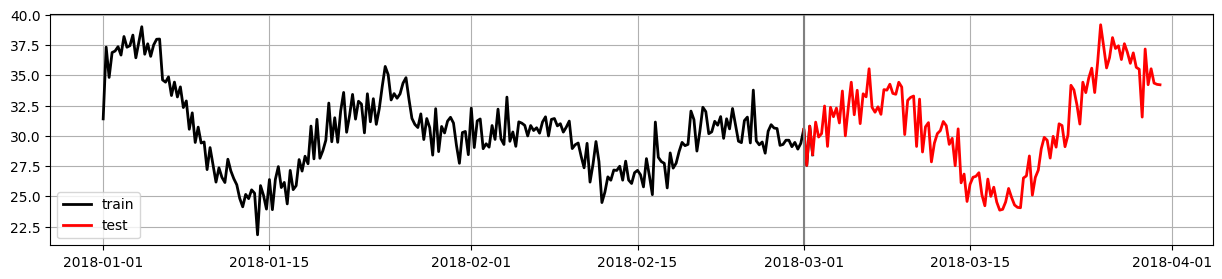

In [ ]:

date_split = "2018-03-01"

idx = pd.date_range("2018-01-01", "2018-03-31", freq="6h")
i = np.linspace(-5,4,len(idx))
i = np.linspace(np.random.random()*5-5,np.random.random()*5+2,len(idx))
t = np.log(i**2+.3)*np.cos(4*i)
t += (np.random.normal(size=len(idx))*.4)
t = np.round(t*3+30,3)
d = pd.DataFrame(np.r_[[t]].T, columns=["signal"], index=idx)
d.index.name="date"

plt.figure(figsize=(15,3))
plt.plot(d[:date_split].index, d[:date_split].signal, color="black", lw="2", label="train");
plt.plot(d[date_split:].index, d[date_split:].signal, color="red", lw="2", label="test");
plt.axvline(date_split, color="grey"); plt.legend();plt.grid();
signal = d


In [ ]:
d.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 357 entries, 2018-01-01 00:00:00 to 2018-03-31 00:00:00
Freq: 6h
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   signal  357 non-null    float64
dtypes: float64(1)
memory usage: 13.7 KB


In [ ]:
d.head(10)

,signal
date,
2018-01-01 00:00:00,31.406
2018-01-01 06:00:00,37.341
2018-01-01 12:00:00,34.833
2018-01-01 18:00:00,36.892
2018-01-02 00:00:00,37.015
2018-01-02 06:00:00,37.374
2018-01-02 12:00:00,36.682
2018-01-02 18:00:00,38.217
2018-01-03 00:00:00,37.332


## Build a time series training dataset

---



 starting off from the time signal above, you must build an **annotated dataset** so that at any time instant **given the three last `n_timesteps_lookback` signal values and the current one** we want to **predict the next one**.


- the column **signal** is left untouched
- there are `n_timesteps_lookback`+1 new columns:
    - the column **signal+1** contains the signal one time step into the future
    - the columns **signal-1**, **signal-2**, etc. contain the signal one, two, etc. time steps into the past.

- the resulting dataset contains (`n_timesteps_lookback`+1) rows less than the original dataset, one due to the **signal+1** column and the rest for the **signal-x** columns. For instance, if the original dataset contained 357 rows, with `n_timesteps_lookback=3` the resulting dataframe will contain 353 rows.


In [ ]:
d

,signal
date,
2018-01-01 00:00:00,31.406
2018-01-01 06:00:00,37.341
2018-01-01 12:00:00,34.833
2018-01-01 18:00:00,36.892
2018-01-02 00:00:00,37.015
...,...
2018-03-30 00:00:00,34.232
2018-03-30 06:00:00,35.549
2018-03-30 12:00:00,34.366


In [ ]:
def make_timeseries_dataset(signal, n_timesteps_lookback):
    import pandas as pd
    df=signal.copy()
    for i in range(1,n_timesteps_lookback+1):
        df[f"signal-{i}"]=df["signal"].shift(i)
    df.drop(df.index[:n_timesteps_lookback],inplace=True) #Esto elimina las n primeras filas que no tienen n señales anteriores
    df["signal+1"]=df["signal"].shift(-1)
    df.drop(df.index[-1],inplace=True)
    return df

In [ ]:
make_timeseries_dataset(d, n_timesteps_lookback=3).head(10)

,signal,signal-1,signal-2,signal-3,signal+1
date,,,,,
2018-01-01 18:00:00,36.892,34.833,37.341,31.406,37.015
2018-01-02 00:00:00,37.015,36.892,34.833,37.341,37.374
2018-01-02 06:00:00,37.374,37.015,36.892,34.833,36.682
2018-01-02 12:00:00,36.682,37.374,37.015,36.892,38.217
2018-01-02 18:00:00,38.217,36.682,37.374,37.015,37.332
2018-01-03 00:00:00,37.332,38.217,36.682,37.374,37.459
2018-01-03 06:00:00,37.459,37.332,38.217,36.682,38.334
2018-01-03 12:00:00,38.334,37.459,37.332,38.217,36.456
2018-01-03 18:00:00,36.456,38.334,37.459,37.332,37.741


## Manually apply a regression model to create predictions


$$\hat{y} = w_0 + w_1s + w_2s_{-1} + w_3s_{-2} + w_4s_{-3} ... $$

where $s$ corresponds to the column named `signal`, $s_{-1}$ to the column named `signal-1`, etc.

Observe that:

- column `signal+1` is not used, as it is the expected prediction.




In [ ]:
def apply_linear_regression_model(td, w):
  r=w[0]+w[1]*td["signal"]
  for i in range(2,len(w)):
    r=r+w[i]*td[f"signal-{i-1}"]
  return np.array(r)

In [ ]:
td = make_timeseries_dataset(d, n_timesteps_lookback=np.random.randint(3)+2)
td = td[np.random.permutation(td.columns)]
td.head()

,signal-2,signal-3,signal,signal+1,signal-1
date,,,,,
2018-01-01 18:00:00,37.341,31.406,36.892,37.015,34.833
2018-01-02 00:00:00,34.833,37.341,37.015,37.374,36.892
2018-01-02 06:00:00,36.892,34.833,37.374,36.682,37.015
2018-01-02 12:00:00,37.015,36.892,36.682,38.217,37.374
2018-01-02 18:00:00,37.374,37.015,38.217,37.332,36.682


In [ ]:
w = np.random.random(len(td.columns))
w

array([0.12491211, 0.04886592, 0.6299768 , 0.19289182, 0.46686768])

In [ ]:
apply_linear_regression_model(td[np.random.permutation(td.columns)], w)[:5]

array([45.73687503, 49.32709476, 48.64838488, 49.82573758, 49.59147571])

## Measure trend prediction

You will now use the predictions to measure **trend accuracy**. We will compare any predictions which are given to us with the actual next value in column **signal+1** in the following way

- if **signal+1>signal** and ALSO your **prediction>signal**, then your model has a **correct trend prediction** regardless how different are **signal+1** and **prediction**
- if **signal+1<=signal** and ALSO your **prediction<=signal**, then your model has a **correct trend prediction** regardless how different are **signal+1** and **prediction**
- otherwise, your model has an **incorrect prediction**



In [ ]:
def measure_trend_accuracy(td, preds):
    return np.mean((td["signal+1"]-td["signal"])*(preds-td["signal"])>=0)

In [ ]:
td = make_timeseries_dataset(d, n_timesteps_lookback=np.random.randint(3)+2).iloc[:10]
td

,signal,signal-1,signal-2,signal-3,signal-4,signal+1
date,,,,,,
2018-01-02 00:00:00,37.015,36.892,34.833,37.341,31.406,37.374
2018-01-02 06:00:00,37.374,37.015,36.892,34.833,37.341,36.682
2018-01-02 12:00:00,36.682,37.374,37.015,36.892,34.833,38.217
2018-01-02 18:00:00,38.217,36.682,37.374,37.015,36.892,37.332
2018-01-03 00:00:00,37.332,38.217,36.682,37.374,37.015,37.459
2018-01-03 06:00:00,37.459,37.332,38.217,36.682,37.374,38.334
2018-01-03 12:00:00,38.334,37.459,37.332,38.217,36.682,36.456
2018-01-03 18:00:00,36.456,38.334,37.459,37.332,38.217,37.741
2018-01-04 00:00:00,37.741,36.456,38.334,37.459,37.332,39.026


In [ ]:
preds = td['signal'] + np.round(np.random.random()*4-2,3)
preds

,signal
date,
2018-01-02 00:00:00,36.781
2018-01-02 06:00:00,37.140
2018-01-02 12:00:00,36.448
2018-01-02 18:00:00,37.983
2018-01-03 00:00:00,37.098
2018-01-03 06:00:00,37.225
2018-01-03 12:00:00,38.100
2018-01-03 18:00:00,36.222
2018-01-04 00:00:00,37.507


In [ ]:
measure_trend_accuracy(td, preds)

np.float64(0.4)